# Macroeconomic Drivers of Soda Consumption in Coca-Cola İçecek Markets (2015-2024)
**Dataset:** 12 Countries · 99 Observations

**Variables:** Population, Non-alcoholic Beverage Consumption, GDP, GDP PPP, Urbanization Rate

**Soda** = Non-alcoholic beverage consumption

**Data from:** CCI Annual/Interim Reports and World Bank open data portal


**Warning:** This study was conducted with a relatively small dataset. Results should be interpreted with caution, as limited sample size may affect the reliability and generalizability of the findings.

## 1. Data Upload

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

colors = {
    "Azerbaijan": "Steelblue", 
    "Iraq": "Darkorange",
    "Jordan": "Green", 
    "Kazakhstan": "Darkblue",
    "Kyrgyzstan": "Salmon", 
    "Pakistan": "Mediumseagreen",
    "Tajikistan": "Gold", 
    "Turkey": "Red",
    "Turkmenistan": "Purple"}

In [2]:
data = pd.read_excel("//Users/mehmedekinelitog/Desktop/Sample_Data/CCI.xlsx")
data.head()

,Year,Country,Population_mn,Soda_per_capita_L,GDP_per_capita,GDP_per_capita_PPP,Urban_population%
0,2015,Azerbaijan,9.8,24,5500.503646,15075.272635,0.552
1,2015,Iraq,36.4,33,4440.141893,9334.466049,0.699
2,2015,Kazakhstan,17.6,38,10196.122626,22484.365138,0.561
3,2015,Kyrgyzstan,5.9,22,1105.651938,4153.376699,0.351
4,2015,Pakistan,188.9,20,1380.470208,4480.263135,0.359


In [ ]:
df = data.copy()

df.columns = df.columns.str.strip()

num_cols = ["Soda_per_capita_L", "GDP_per_capita", "GDP_per_capita_PPP", "Urban_population%"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

if df["Urban_population%"].max() <= 1:
    df["Urban_population%"] = df["Urban_population%"] * 100

miss = df.isnull().sum()
print(f"Miss: \n{miss}")

core_list = df["Country"].value_counts()
core_list = core_list[core_list >= 8].index.tolist()
df_core = df[df["Country"].isin(core_list)].copy()

countries = sorted(df_core["Country"].unique())
years = sorted(df_core["Year"].unique())

print(f"Countries: {countries}")

Miss: 
Year                  0
Country               0
Population_mn         0
Soda_per_capita_L     4
GDP_per_capita        2
GDP_per_capita_PPP    4
Urban_population%     1
dtype: int64
Countries: ['Azerbaijan', 'Iraq', 'Jordan', 'Kazakhstan', 'Kyrgyzstan', 'Pakistan', 'Tajikistan', 'Turkey', 'Turkmenistan']


In [4]:
df_core[["Soda_per_capita_L", "GDP_per_capita", "GDP_per_capita_PPP", "Urban_population%"]].describe().round(2)

,Soda_per_capita_L,GDP_per_capita,GDP_per_capita_PPP,Urban_population%
count,89.00,90.00,90.00,90.00
mean,62.44,5132.77,14808.42,56.95
std,40.99,3642.24,10695.31,21.96
min,9.00,788.71,2913.86,26.10
25%,31.70,1461.18,5488.60,36.48
50%,49.00,4542.09,12141.50,56.95
75%,92.30,7063.94,22166.55,69.90
max,181.80,15892.72,45639.02,93.00


## 2. Exploratory Data Analysis (EDA)

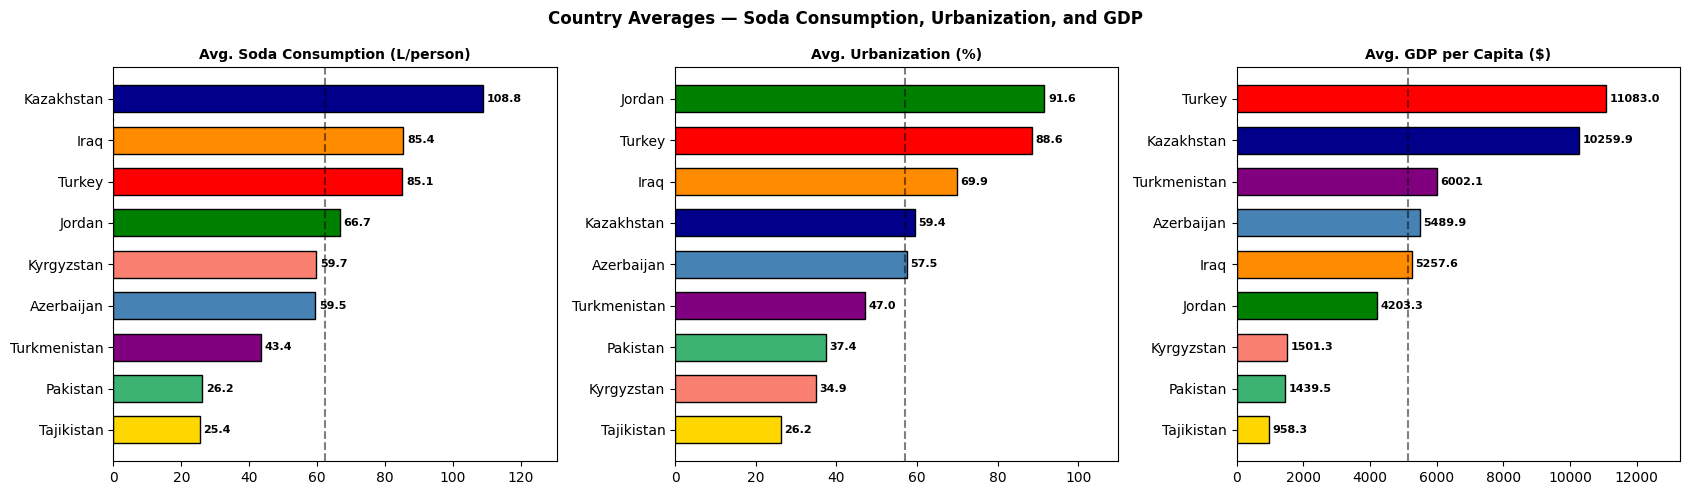

In [19]:
avg = df_core.groupby("Country").agg(Soda=("Soda_per_capita_L", "mean"), Urban=("Urban_population%", "mean"), GDP=("GDP_per_capita", "mean")).round(2)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Country Averages — Soda Consumption, Urbanization, and GDP", fontsize=12, fontweight="bold", color="Black")

for ax, col, label in zip(
    axes,
    ["Soda", "Urban", "GDP"], ["Avg. Soda Consumption (L/person)", "Avg. Urbanization (%)", "Avg. GDP per Capita ($)"]):
    data = avg[col].sort_values()
    bar_colors = [colors.get(c, "gray") for c in data.index]
    bars = ax.barh(data.index, data.values, color=bar_colors, height=0.65, edgecolor="Black")
    for bar, val in zip(bars, data.values):
        ax.text(val + data.max() * 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.1f}", va="center", fontsize=8, color="Black", fontweight="bold")
    ax.axvline(data.mean(), color="Black", linestyle="--", alpha=0.5)
    ax.set_xlim(0, data.max() * 1.2)
    ax.set_title(label, fontsize=10, fontweight="bold")

plt.tight_layout()

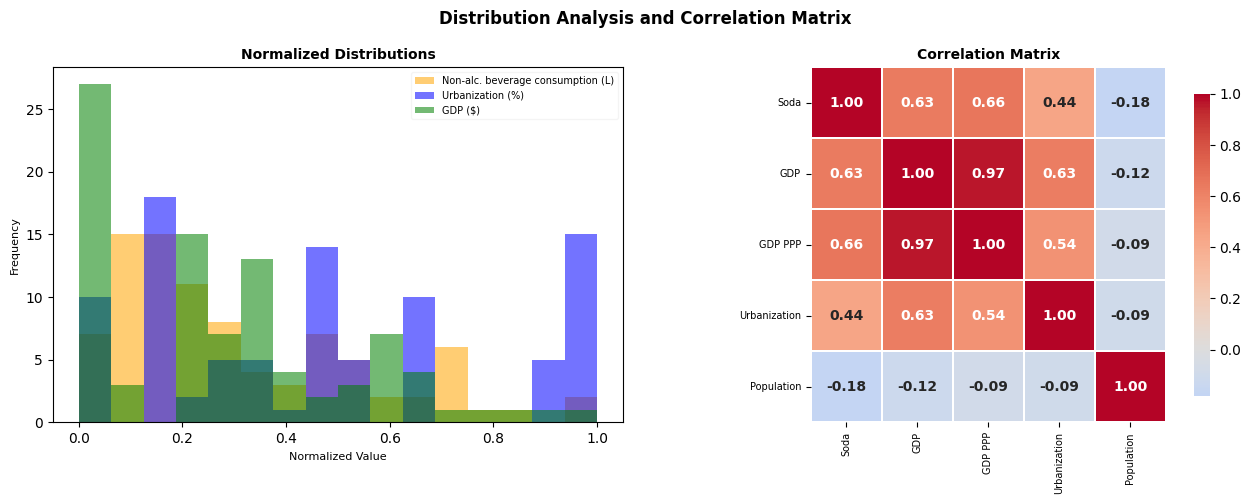

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribution Analysis and Correlation Matrix", fontsize=12, fontweight="bold")

ax = axes[0]
cols_hist = ["Soda_per_capita_L", "Urban_population%", "GDP_per_capita"]
colors_h = ["Orange", "Blue", "Green"]
labels_h = ["Non-alc. beverage consumption (L)", "Urbanization (%)", "GDP ($)"]

for i, (col, color, lbl) in enumerate(zip(cols_hist, colors_h, labels_h)):
    vals = df_core[col].dropna()
    norm = (vals - vals.min()) / (vals.max() - vals.min())
    ax.hist(norm, bins=16, color=color, alpha=0.55, label=lbl)
ax.set_xlabel("Normalized Value", fontsize=8)
ax.set_ylabel("Frequency", fontsize=8)
ax.set_title("Normalized Distributions", fontsize=10, fontweight="bold")
ax.legend(fontsize=7, framealpha=0.2)

corr_cols = ["Soda_per_capita_L", "GDP_per_capita", "GDP_per_capita_PPP", "Urban_population%", "Population_mn"]
corr_labels = ["Soda", "GDP", "GDP PPP", "Urbanization", "Population"]
corr_m = df_core[corr_cols].dropna().corr()
corr_m.index = corr_labels
corr_m.columns = corr_labels

sns.heatmap(corr_m, ax=axes[1], annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=1.2, annot_kws={"size":10, "weight":"bold"}, cbar_kws={"shrink": 0.85})
axes[1].set_title("Correlation Matrix", fontsize=10, fontweight="bold")
axes[1].tick_params(labelsize=7)

plt.tight_layout()

## 3. Trend Analysis

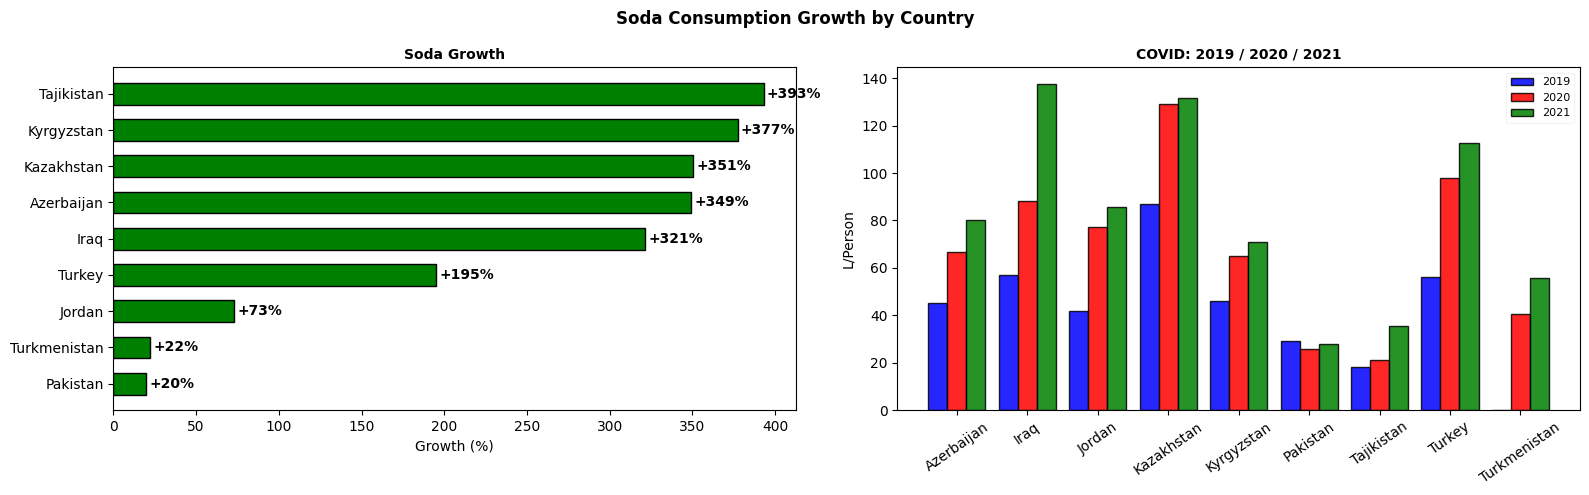

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Soda Consumption Growth by Country", fontsize=12, fontweight="bold")

growth_data = []
for c in countries:
    sub = (df_core[df_core["Country"] == c].sort_values("Year").dropna(subset=["Soda_per_capita_L"]))
    if len(sub) >= 6:
        g = (sub["Soda_per_capita_L"].iloc[-1] / sub["Soda_per_capita_L"].iloc[0] - 1) * 100
        growth_data.append({"Country":c, "Growth":g})
gdf = pd.DataFrame(growth_data).sort_values("Growth")

bars = axes[0].barh(gdf["Country"], gdf["Growth"], height=0.6, color="Green", edgecolor="Black")
for bar, val in zip(bars, gdf["Growth"]):
    xpos = val + 2 if val >= 0 else val - 2
    axes[0].text(xpos, bar.get_y() + bar.get_height()/2, f"{val:+.0f}%", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Growth (%)", fontsize=10)
axes[0].set_title("Soda Growth", fontsize=10, fontweight="bold")

covid_data = []
for c in countries:
    sub = df_core[df_core["Country"] == c].set_index("Year")
    for yr in [2019, 2020, 2021]:
        if yr in sub.index:
            v = sub.loc[yr, "Soda_per_capita_L"]
            if pd.notna(v):
                covid_data.append({"Country": c, "Year": yr, "Soda": v})
cdf = pd.DataFrame(covid_data)

x = np.arange(len(countries))
w = 0.27
yr_colors = {2019:"Blue", 2020:"Red", 2021:"Green"}
for i, yr in enumerate([2019, 2020, 2021]):
    vals = [cdf[(cdf["Country"]==c)&(cdf["Year"]==yr)]["Soda"].values
            for c in countries]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    axes[1].bar(x + (i-1)*w, vals, w, label=str(yr), color=yr_colors[yr], alpha=0.85, edgecolor="Black")
axes[1].set_xticks(x)
axes[1].set_xticklabels(countries, rotation=35, fontsize=10)
axes[1].set_ylabel("L/Person", fontsize=10)
axes[1].set_title("COVID: 2019 / 2020 / 2021", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=8, framealpha=0.2)

plt.tight_layout()

## 4. The Relationship Between GDP and Soda

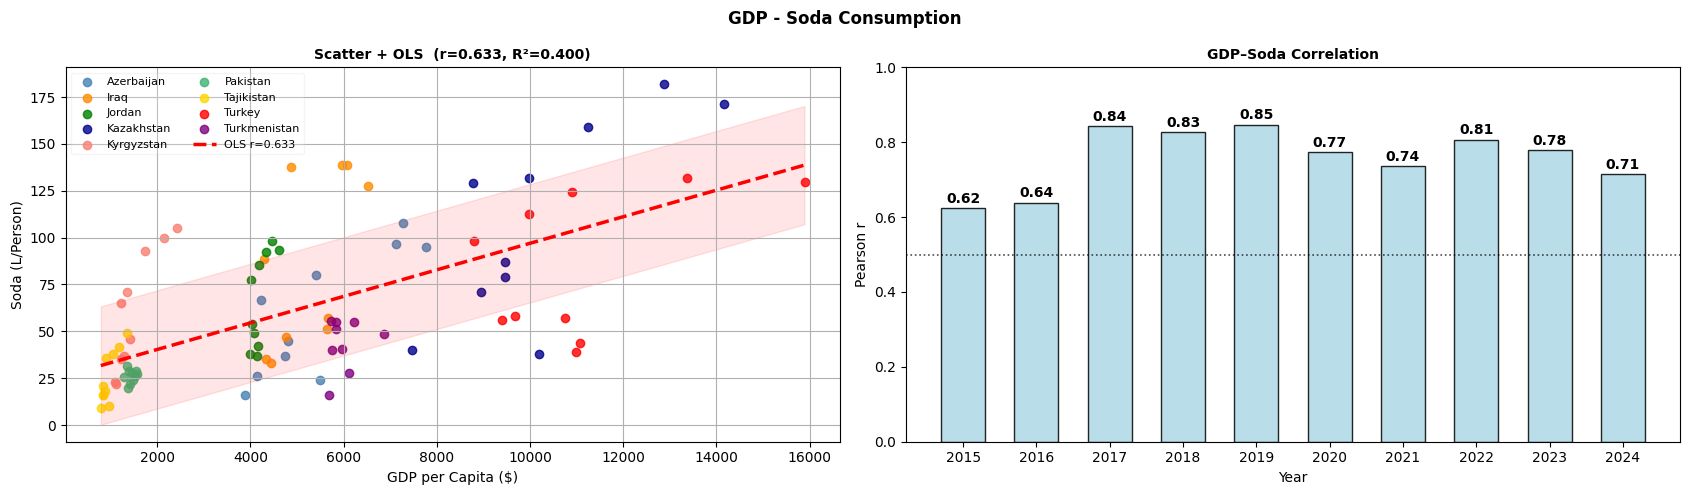

In [ ]:
sd = df_core.dropna(subset=["GDP_per_capita", "Soda_per_capita_L"])

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle("GDP - Soda Consumption", fontsize=12, fontweight="bold")

ax = axes[0]
for c in countries:
    sub = sd[sd["Country"] == c]
    ax.scatter(sub["GDP_per_capita"], sub["Soda_per_capita_L"], color=colors.get(c), alpha=0.8, label=c)
x_v = sd["GDP_per_capita"].values
y_v = sd["Soda_per_capita_L"].values
slope, intercept, r_val, p_val, se = stats.linregress(x_v, y_v)
xl = np.linspace(x_v.min(), x_v.max(), 300)
y_std = np.std(y_v - (slope * x_v + intercept))
ax.fill_between(xl, slope*xl+intercept-y_std, slope*xl+intercept+y_std, alpha=0.10, color="Red")
ax.plot(xl, slope*xl+intercept, "--", color="Red", lw=2.5, label=f"OLS r={r_val:.3f}")
ax.set_xlabel("GDP per Capita ($)", fontsize=10)
ax.set_ylabel("Soda (L/Person)", fontsize=10)
ax.set_title(f"Scatter + OLS  (r={r_val:.3f}, R²={r_val**2:.3f})", fontsize=10, fontweight="bold")
ax.legend(fontsize=8, ncol=2, framealpha=0.2)
ax.grid(zorder=0)

ax2 = axes[1]
corr_yr = []
for yr in years:
    sub = sd[sd["Year"] == yr]
    if len(sub) >= 4:
        r, p = stats.pearsonr(sub["GDP_per_capita"], sub["Soda_per_capita_L"])
        corr_yr.append({"Year":yr, "r":r})
cyr_df = pd.DataFrame(corr_yr)
bars2 = ax2.bar(cyr_df["Year"], cyr_df["r"], color="Lightblue", alpha=0.85, width=0.6, edgecolor="Black")
for bar, val in zip(bars2, cyr_df["r"]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.015, f"{val:.2f}", ha="center", fontsize=10, color="Black", fontweight="bold")
ax2.axhline(0.5, color="Black", lw=1.2, linestyle=":", alpha=0.7)
ax2.set_xlabel("Year", fontsize=10)
ax2.set_ylabel("Pearson r", fontsize=10)
ax2.set_title("GDP–Soda Correlation", fontsize=10, fontweight="bold")
ax2.set_ylim(0, 1.0)
ax2.set_xticks(cyr_df["Year"])

plt.tight_layout()

The OLS regression confirms a statistically significant positive relationship between GDP per capita and soda consumption: Soda = 0.00708 × GDP + 26.16 (R² = 0.40, p < 0.001). This means approximately 40% of the variation in soda consumption across observations can be explained by GDP per capita alone. The year by year Pearson correlation remains consistently above 0.5 for most years, indicating that the GDP soda relationship is stable over time and not driven by a single outlier year.

## 5. The Relationship Between Urbanization and Soda

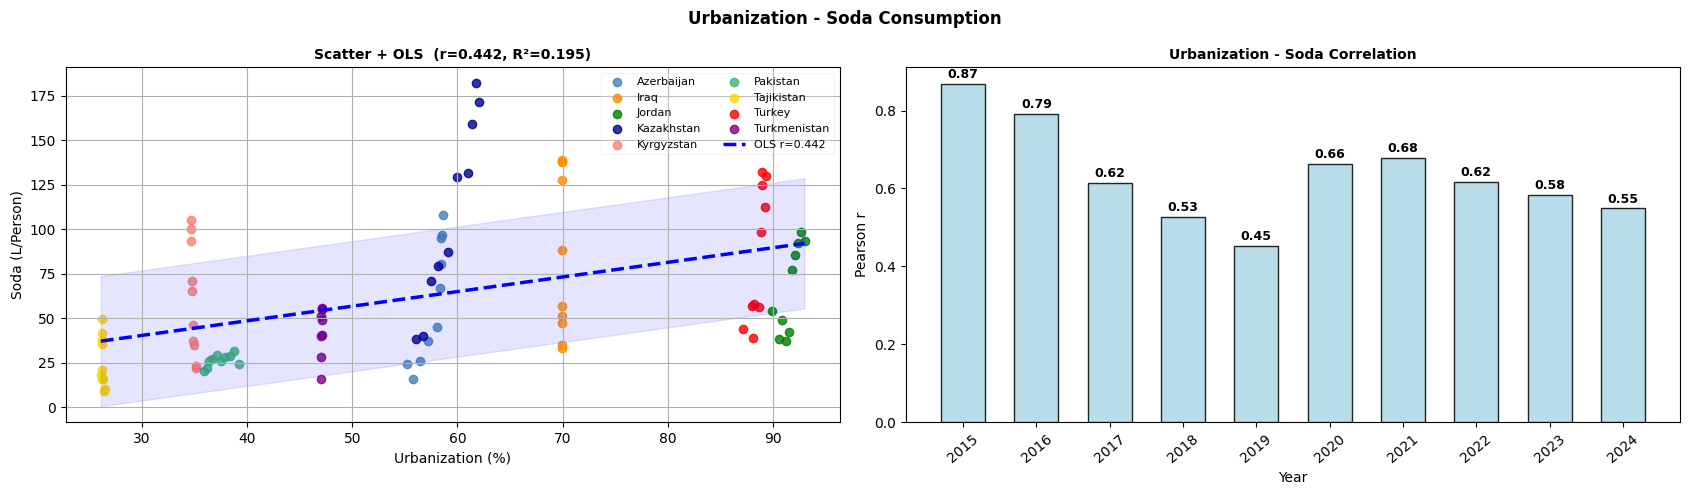

In [ ]:
ud = df_core.dropna(subset=["Urban_population%", "Soda_per_capita_L"])

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle("Urbanization - Soda Consumption", fontsize=12, fontweight="bold")

ax = axes[0]
for c in countries:
    sub = ud[ud["Country"] == c]
    ax.scatter(sub["Urban_population%"], sub["Soda_per_capita_L"], color=colors.get(c), alpha=0.8, label=c)
xu = ud["Urban_population%"].values
yu = ud["Soda_per_capita_L"].values
slope_u, intercept_u, r_u, p_u, _ = stats.linregress(xu, yu)
xl_u = np.linspace(xu.min(), xu.max(), 300)
y_std_u = np.std(yu - (slope_u * xu + intercept_u))
ax.fill_between(xl_u, slope_u*xl_u+intercept_u-y_std_u, slope_u*xl_u+intercept_u+y_std_u, alpha=0.10, color="Blue")
ax.plot(xl_u, slope_u*xl_u+intercept_u, "--", color="Blue", lw=2.5, label=f"OLS r={r_u:.3f}")
ax.set_xlabel("Urbanization (%)", fontsize=10)
ax.set_ylabel("Soda (L/Person)", fontsize=10)
ax.set_title(f"Scatter + OLS  (r={r_u:.3f}, R²={r_u**2:.3f})", fontsize=10, fontweight="bold")
ax.legend(fontsize=8, ncol=2, framealpha=0.2)
ax.grid(zorder=0)

ax2 = axes[1]
corr_urban_yr = []
for yr in years:
    sub = ud[ud["Year"] == yr]
    if len(sub) >= 4:
        r, p = stats.pearsonr(sub["Urban_population%"], sub["Soda_per_capita_L"])
        corr_urban_yr.append({"Year":yr, "r":r})
cuyr_df = pd.DataFrame(corr_urban_yr)
bars_u = ax2.bar(cuyr_df["Year"], cuyr_df["r"], color="Lightblue", alpha=0.85, width=0.6, zorder=3, edgecolor="Black")
for bar, val in zip(bars_u, cuyr_df["r"]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.015, f"{val:.2f}", ha="center", fontsize=9, color="Black", fontweight="bold")
ax2.set_xlabel("Year", fontsize=10)
ax2.set_ylabel("Pearson r", fontsize=10)
ax2.set_title("Urbanization - Soda Correlation", fontsize=10, fontweight="bold")
ax2.set_xticks(cuyr_df["Year"])
ax2.tick_params(axis="x", rotation=40)

plt.tight_layout()

Urbanization shows a moderate positive association with soda consumption: Soda = 0.82 × Urbanization + 15.58 (R² = 0.20, p < 0.001). While statistically significant, urbanization explains only 20% of the variance, roughly half the explanatory power of GDP. This suggests that income growth is a stronger driver of soda consumption than urban migration alone. Highly urbanized countries like Jordan (91.6%) and Turkey (88.6%) do show high soda consumption, but the relationship is noisier than for GDP.


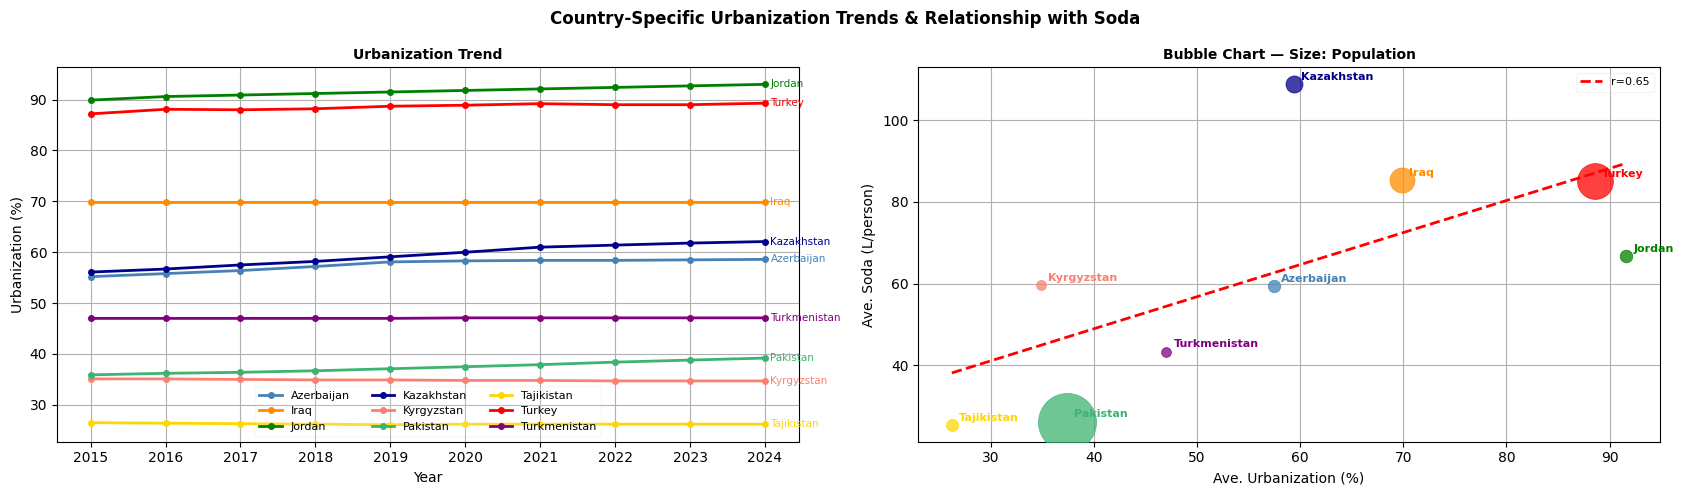

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle("Country-Specific Urbanization Trends & Relationship with Soda", fontsize=12, fontweight="bold")

ax = axes[0]
for c in countries:
    sub = (df_core[df_core["Country"] == c].sort_values("Year").dropna(subset=["Urban_population%"]))
    if len(sub) < 2:
        continue
    ax.plot(sub["Year"], sub["Urban_population%"], color=colors.get(c), lw=2, marker="o", markersize=4, label=c, zorder=3)
    last = sub.iloc[-1]
    ax.annotate(c, xy=(last["Year"], last["Urban_population%"]), xytext=(4, 0), textcoords="offset points", fontsize=7.5, color=colors.get(c), va="center")
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Urbanization (%)", fontsize=10)
ax.set_title("Urbanization Trend", fontsize=10, fontweight="bold")
ax.set_xticks(years)
ax.legend(fontsize=8, ncol=3, framealpha=0.15)
ax.grid(zorder=0)

ax2 = axes[1]
avg2 = df_core.groupby("Country").agg(Soda=("Soda_per_capita_L", "mean"), Urban=("Urban_population%", "mean"), Pop=("Population_mn", "mean")).dropna()
for c, row in avg2.iterrows():
    size = max(row["Pop"] * 8, 50)
    ax2.scatter(row["Urban"], row["Soda"], color=colors.get(c), s=size, alpha=0.75, zorder=4, linewidths=0.6)
    ax2.annotate(c, (row["Urban"], row["Soda"]), xytext=(5, 3), textcoords="offset points", fontsize=8, color=colors.get(c), fontweight="bold")
x2 = avg2["Urban"].values
y2 = avg2["Soda"].values
sl2, ic2, rv2, _, _ = stats.linregress(x2, y2)
xl2 = np.linspace(x2.min(), x2.max(), 200)
ax2.plot(xl2, sl2*xl2+ic2, "--", color="Red", lw=2, label=f"r={rv2:.2f}", zorder=5)
ax2.set_xlabel("Ave. Urbanization (%)", fontsize=10)
ax2.set_ylabel("Ave. Soda (L/person)", fontsize=10)
ax2.set_title("Bubble Chart — Size: Population", fontsize=10, fontweight="bold")
ax2.legend(fontsize=8, framealpha=0.2)
ax2.grid(zorder=0)

plt.tight_layout()

## 6. Multivariable Analysis

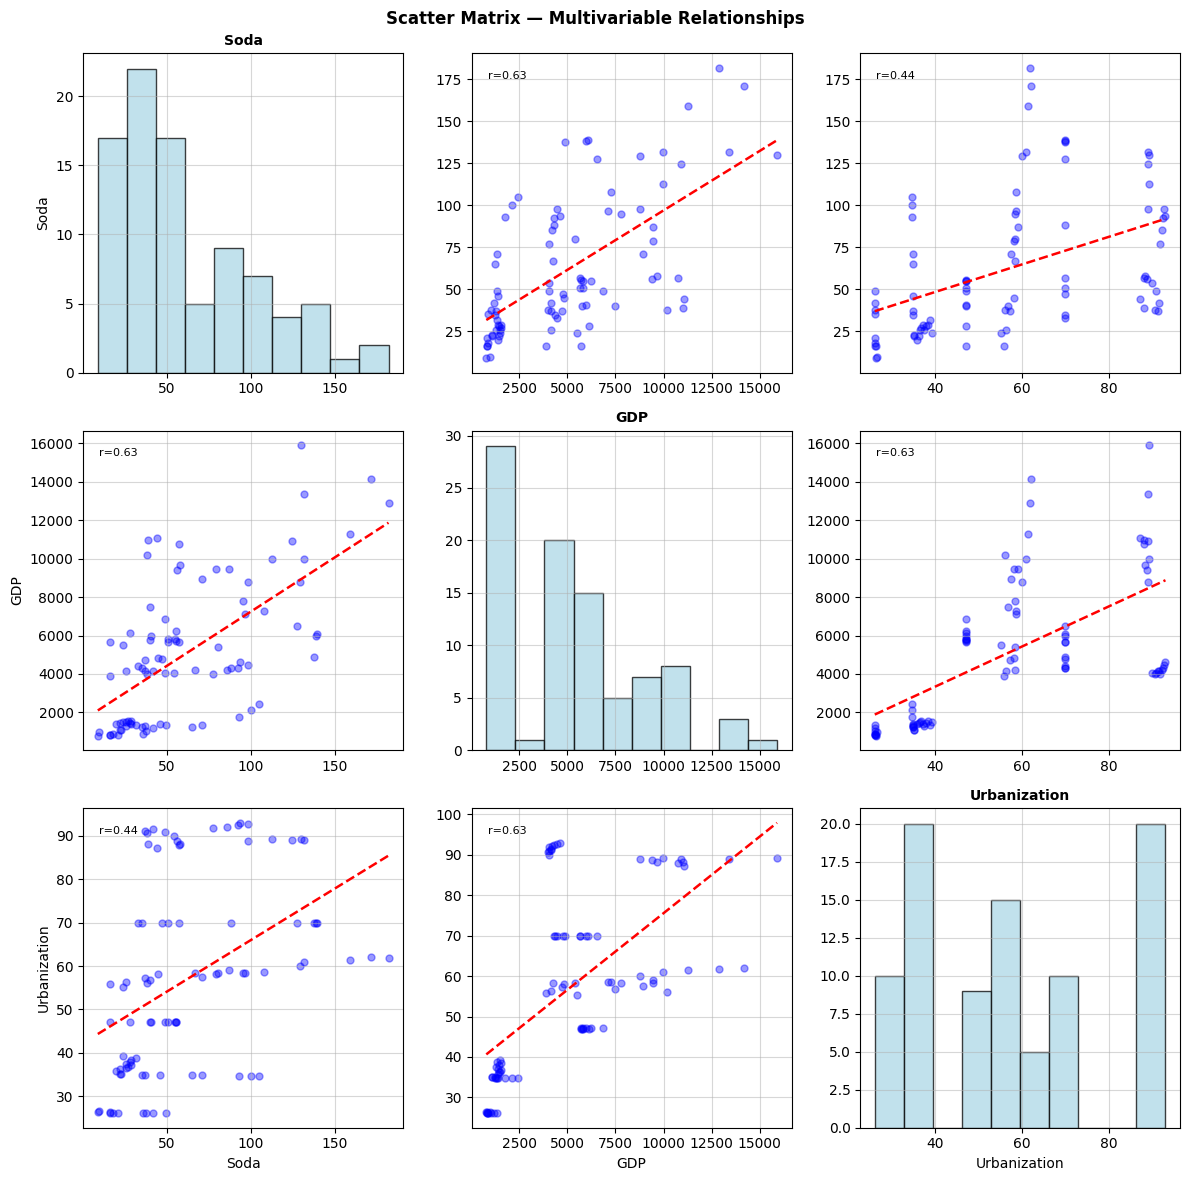

In [11]:
mv = df_core[["Soda_per_capita_L", "GDP_per_capita", "Urban_population%", "Population_mn"]].dropna()
mv.columns = ["Soda", "GDP", "Urbanization", "Population"]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("Scatter Matrix — Multivariable Relationships", fontsize=12, fontweight="bold")

cols4 = ["Soda", "GDP", "Urbanization"]
for i, ci in enumerate(cols4):
    for j, cj in enumerate(cols4):
        ax = axes[i][j]
        if i == j:
            ax.hist(mv[ci].dropna(), color="Lightblue", alpha=0.75, edgecolor="Black")
            ax.set_title(ci, fontsize=10, fontweight="bold")
        else:
            x_mv = mv[cj].values
            y_mv = mv[ci].values
            ax.scatter(x_mv, y_mv, color="Blue", alpha=0.4, s=25)
            sl_mv, ic_mv, rv_mv, _, _ = stats.linregress(x_mv, y_mv)
            xl_mv = np.linspace(x_mv.min(), x_mv.max(), 100)
            ax.plot(xl_mv, sl_mv*xl_mv+ic_mv, color="Red", lw=1.8, linestyle="--")
            ax.text(0.05, 0.92, f"r={rv_mv:.2f}", transform=ax.transAxes, fontsize=8, color="Black")
        if j == 0:
            ax.set_ylabel(ci, fontsize=10)
        if i == 2:
            ax.set_xlabel(cj, fontsize=10)
        ax.grid(zorder=0, alpha=0.5)

plt.tight_layout()

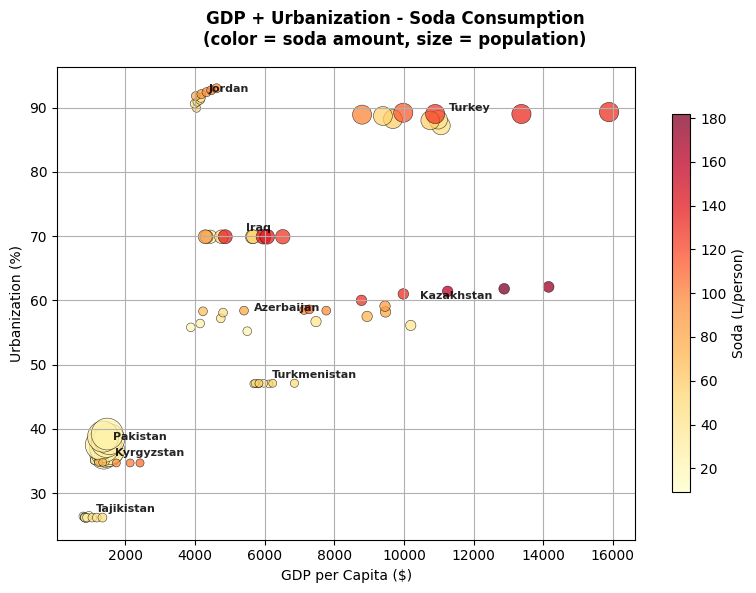

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
fig.suptitle("GDP + Urbanization - Soda Consumption\n(color = soda amount, size = population)", fontsize=12, fontweight="bold")

plot_df = df_core.dropna(subset=["GDP_per_capita", "Urban_population%", "Soda_per_capita_L"])
sc = ax.scatter(plot_df["GDP_per_capita"], plot_df["Urban_population%"], c=plot_df["Soda_per_capita_L"], s=plot_df["Population_mn"] * 2 + 20, cmap="YlOrRd", alpha=0.75, edgecolors="Black", linewidths=0.4)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("Soda (L/person)", fontsize=10, color="Black")
cbar.ax.yaxis.set_tick_params(color="Black")

for c in countries:
    sub = plot_df[plot_df["Country"] == c]
    if len(sub) == 0:
        continue
    mx = sub["GDP_per_capita"].mean()
    my = sub["Urban_population%"].mean()
    ax.annotate(c, (mx, my), xytext=(5, 4), textcoords="offset points", fontsize=8, color="Black", fontweight="bold", alpha=0.85)

ax.set_xlabel("GDP per Capita ($)", fontsize=10)
ax.set_ylabel("Urbanization (%)", fontsize=10)
ax.grid(zorder=0)

plt.tight_layout()

## 7. Statistical Tests

In [13]:
clean = df_core.dropna(subset=["GDP_per_capita", "Urban_population%", "Soda_per_capita_L"])

print("Correlations")
for var, label in [("GDP_per_capita","GDP"), ("Urban_population%","Urbanization"), ("GDP_per_capita_PPP","GDP PPP")]:
    sub = df_core.dropna(subset=[var,"Soda_per_capita_L"])
    r_p,p_p = stats.pearsonr(sub[var], sub["Soda_per_capita_L"])
    r_s,p_s = stats.spearmanr(sub[var], sub["Soda_per_capita_L"])
    print(f"{label}:")
    print(f"Pearson r={r_p:.4f} p={p_p:.4e}")
    print(f"Spearman r={r_s:.4f} p={p_s:.4e}\n")

Correlations
GDP:
Pearson r=0.6326 p=2.9195e-11
Spearman r=0.6518 p=4.5932e-12

Urbanization:
Pearson r=0.4420 p=1.4512e-05
Spearman r=0.5521 p=2.0427e-08

GDP PPP:
Pearson r=0.6622 p=1.5831e-12
Spearman r=0.6691 p=7.6550e-13



All three macroeconomic variables are significantly correlated with soda consumption (p < 0.001). GDP PPP shows the strongest association (Pearson r = 0.662, Spearman r = 0.669), slightly outperforming nominal GDP (Pearson r = 0.633). This suggests that purchasing power not just raw income is the primary economic driver of soda demand. Urbanization has a moderate but significant relationship (Pearson r = 0.442, Spearman r = 0.552), with the higher Spearman coefficient indicating a non linear monotonic pattern.


In [14]:
print("Normality Test (Shapiro Wilk)")
for col, label in [("Soda_per_capita_L","Soda"), ("Urban_population%","Urbanization"), ("GDP_per_capita","GDP")]:
    v = df_core[col].dropna()
    w, p = stats.shapiro(v)
    print(f"{label:15s} W={w:.4f} p={p:.4f}")

Normality Test (Shapiro Wilk)
Soda            W=0.8995 p=0.0000
Urbanization    W=0.9095 p=0.0000
GDP             W=0.9142 p=0.0000


All three variables fail the "Shapiro Wilk" normality test (p < 0.0001), confirming that none of them follow a normal distribution. This justifies the use of non parametric tests(Spearman correlation, Kruskal Wallis) alongside standard OLS regression, and means that parametric significance thresholds should be interpreted with caution.

In [15]:
print("Kruskal Wallis (difference between countries)")
grps = [df_core[df_core["Country"]==c]["Soda_per_capita_L"].dropna() for c in countries]
h,p = stats.kruskal(*grps)
print(f"H={h:.4f} p={p:.4e}")

Kruskal Wallis (difference between countries)
H=41.2768 p=1.8503e-06


The "Kruskal Wallis" test yields H = 41.28, p < 0.001, confirming that soda consumption levels differ significantly across countries. This means country level fixed effects matter consumption patterns are not simply explained by macroeconomic variables alone, and country-specific factors (culture, market penetration, pricing, distribution) also play a meaningful role.

In [16]:
print("OLS Regression Summary")
for var, label in [("GDP_per_capita","GDP"), ("Urban_population%","Urbanization")]:
    sub = df_core.dropna(subset=[var,"Soda_per_capita_L"])
    sl, ic, rv, pv, se = stats.linregress(sub[var], sub["Soda_per_capita_L"])
    print(f"\nIndependent variable: {label}")
    print(f"Equation: Soda = {sl:.5f} × {label} + {ic:.2f}")
    print(f"R²: {rv**2:.4f}")
    print(f"p-value: {pv:.4e}")

OLS Regression Summary

Independent variable: GDP
Equation: Soda = 0.00708 × GDP + 26.16
R²: 0.4002
p-value: 2.9195e-11

Independent variable: Urbanization
Equation: Soda = 0.82127 × Urbanization + 15.58
R²: 0.1953
p-value: 1.4512e-05


GDP per capita is the stronger single predictor of soda consumption (R² = 0.40) compared to urbanization (R² = 0.20). The GDP regression equation implies that each additional $1,000 in GDP per capita is associated with approximately 7.1 extra liters of soda consumed per person per year. For urbanization, a 10 percentag point increase in the urban population share is associated with roughly 8.2 extra liters. Both predictors are highly significant (p < 0.001), but together they still leave substantial unexplained variance, pointing to the importance of country specific and cultural factors.

## 8. Conclusions

This analysis examined the macroeconomic drivers of soda consumption across nine Coca Cola İçecek markets between 2015 and 2024. The key findings are as follows:

- GDP per capita (PPP) is the strongest single predictor of per-capita soda consumption (r = 0.662, R² = 0.40), underscoring that purchasing power is more decisive than raw income.
- Urbanization has a moderate, statistically significant positive effect (r = 0.442, R² = 0.20), but it explains considerably less variation than GDP, suggesting urban migration alone is insufficient to drive consumption without accompanying income growth.
- High-growth markets such as Tajikistan, Kyrgyzstan, and Kazakhstan grew by over 350% from a low base, indicating significant untapped demand in lower income CCI markets.
- The "Kruskal Wallis" test confirms that country specific factors beyond macroeconomics significantly differentiate consumption levels, pointing to the importance of market level strategies in pricing, distribution, and brand penetration.

Overall, the analysis shows that rising GDP per capita and increasing urbanization rates are the two most important macroeconomic conditions that drive higher soda consumption across CCI markets. However, these factors alone do not fully explain the differences between countries as seen with Iraq outperforming Jordan despite lower urbanization, or Pakistan remaining a low consumption market despite its large population. This suggests that macroeconomic improvement creates the demand potential, but factors such as pricing strategy, distribution network strength, brand awareness, and local consumer habits ultimately determine how much of that potential is captured in each market.